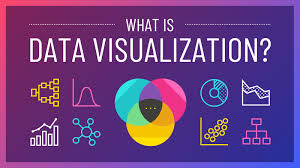

## 🥸 Exploratory data analysis

### 🎒 Packages

In [42]:
from pathlib import Path
import matplotlib.pyplot as plt
import pandas as pd
# pd.set_option('display.max_colwidth', None)
import seaborn as sns

import nltk
from nltk.tokenize import word_tokenize
import random

from nltk.corpus import stopwords
from collections import Counter
import re

from wordcloud import WordCloud

### 🚙 Utilities

#### nltk packages downloading

In [22]:
nltk.download('punkt_tab')
nltk.download('stopwords')

[nltk_data] Downloading package punkt_tab to /home/zun/nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!
[nltk_data] Downloading package stopwords to /home/zun/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


True

In [23]:
train_path = Path("..") / "data" / "train" / "train.tsv"
# only used for final outputing (estimation on real data)
test_path = Path("..") / "data" / "test" / "train.tsv"

#### random colors for plot

In [24]:
pastel_colors = sns.color_palette("pastel")

In [25]:
def color():
    color = random.choice(pastel_colors)
    return color

### 📊 Data

#### 🥐 Read the tsv file

Mapping between numbers in `Sentiment` and actually sentiment
- 0 - 😡 negative
- 1 - 😤 somewhat negative
- 2 - 😐 neutral
- 3 - 😀 somewhat positive
- 4 - 😁 positive

In [26]:
df = pd.read_csv(
    train_path,
    sep="\t"
)

df.info()

<class 'pandas.DataFrame'>
RangeIndex: 156060 entries, 0 to 156059
Data columns (total 4 columns):
 #   Column      Non-Null Count   Dtype
---  ------      --------------   -----
 0   PhraseId    156060 non-null  int64
 1   SentenceId  156060 non-null  int64
 2   Phrase      156060 non-null  str  
 3   Sentiment   156060 non-null  int64
dtypes: int64(3), str(1)
memory usage: 4.8 MB


In [27]:
eda_df = df.copy()

In [28]:
sentiment_mappings = {
    0 : "negative",
    1 : "somewhat negative",
    2 : "neural",
    3 : "somewhat positive",
    4 : "positive"
}

icon_mappings = {
    0 : "😡",
    1 : "😤",
    2 : "😐",
    3 : "😐",
    4 : "😁"
}

eda_df["SentimentName"] = eda_df["Sentiment"].map(sentiment_mappings)
eda_df["Icon"] = eda_df["Sentiment"].map(icon_mappings)

In [41]:
eda_df.info()

<class 'pandas.DataFrame'>
RangeIndex: 156060 entries, 0 to 156059
Data columns (total 6 columns):
 #   Column         Non-Null Count   Dtype
---  ------         --------------   -----
 0   PhraseId       156060 non-null  int64
 1   SentenceId     156060 non-null  int64
 2   Phrase         156060 non-null  str  
 3   Sentiment      156060 non-null  int64
 4   SentimentName  156060 non-null  str  
 5   Icon           156060 non-null  str  
dtypes: int64(3), str(3)
memory usage: 7.1 MB


In [29]:
# with pd.option_context("display.max_colwidth", None):
eda_df.head(5)

,PhraseId,SentenceId,Phrase,Sentiment,SentimentName,Icon
0,1,1,A series of escapades demonstrating the adage ...,1,somewhat negative,😤
1,2,1,A series of escapades demonstrating the adage ...,2,neural,😐
2,3,1,A series,2,neural,😐
3,4,1,A,2,neural,😐
4,5,1,series,2,neural,😐


### 

### 😚 Exploratory data analysis

#### 🤼‍♂️ Merge sentence phrases into a full sentence

In [30]:
phrases = eda_df[["SentenceId", "Phrase"]]

idx = phrases['Phrase'].str.len().groupby(phrases['SentenceId']).idxmax()
sentences_df = phrases.loc[idx].reset_index(drop=True)

sentences_df

,SentenceId,Phrase
0,1,A series of escapades demonstrating the adage ...
1,2,"This quiet , introspective and entertaining in..."
2,3,"Even fans of Ismail Merchant 's work , I suspe..."
3,4,A positively thrilling combination of ethnogra...
4,5,Aggressive self-glorification and a manipulati...
...,...,...
8524,8540,... either you 're willing to go with this cla...
8525,8541,"Despite these annoyances , the capable Claybur..."
8526,8542,-LRB- Tries -RRB- to parody a genre that 's al...
8527,8543,The movie 's downfall is to substitute plot fo...


##### 💯 Result:
- There are 8529 independent sentences, the other sentences are generated using the technique "Each Sentence has been parsed into many phrases by the Stanford parser"

#### 😞 What is the class distribution of the dataset?

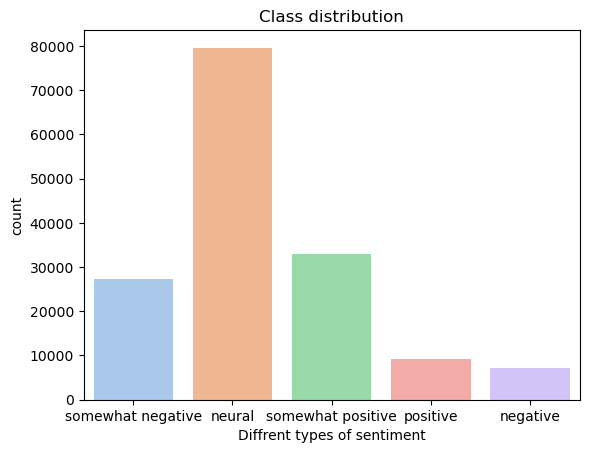

In [31]:
dist_df = eda_df.copy()

sns.countplot(data=dist_df, x="SentimentName", palette="pastel", hue="SentimentName")

plt.title("Class distribution")
plt.xlabel("Diffrent types of sentiment")
plt.show()

##### 💯 Result
---
- The dataset is imbalanced
- The number of neural samples dominates the other, the number of positive and negative sample are too small
##### 🌳 Possible decisions:
---
- Find a way to fix this imbalance?
- Oversampling/Undersampling

#### 🤧 What is the number of word/token per phrase?

In [32]:
word_count_df = eda_df.copy()

In [33]:
def get_word_count(row):
    tokens = word_tokenize(text=row["Phrase"])
    return len(tokens)

def get_character_count(row):
    return len(row["Phrase"])

In [34]:
word_count_df["WordCount"] = word_count_df.apply(get_word_count, axis=1)
word_count_df["CharacterCount"] = word_count_df.apply(get_character_count, axis=1)

In [35]:
word_count_df.head()

,PhraseId,SentenceId,Phrase,Sentiment,SentimentName,Icon,WordCount,CharacterCount
0,1,1,A series of escapades demonstrating the adage ...,1,somewhat negative,😤,37,188
1,2,1,A series of escapades demonstrating the adage ...,2,neural,😐,14,77
2,3,1,A series,2,neural,😐,2,8
3,4,1,A,2,neural,😐,1,1
4,5,1,series,2,neural,😐,1,6


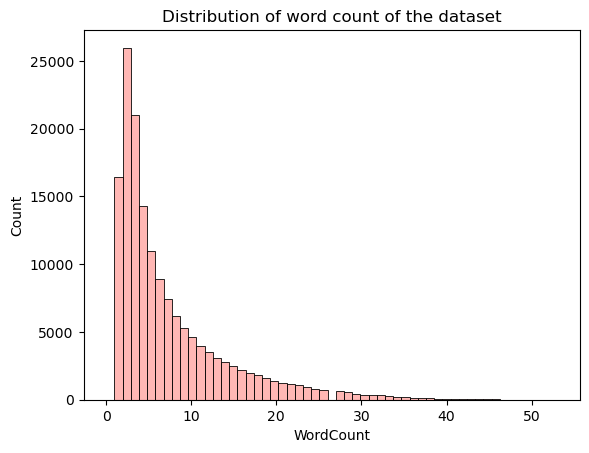

In [36]:
sns.histplot(data=word_count_df, x="WordCount", color=color(), bins=55)

plt.title("Distribution of word count of the dataset")
plt.show()

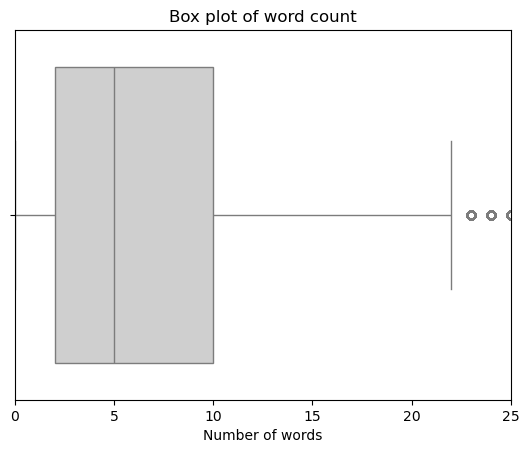

In [37]:
sns.boxplot(data=word_count_df, x="WordCount", color=color())

plt.xlim((0, 25))
plt.xlabel("Number of words")
plt.title("Box plot of word count")
plt.show()

In [38]:
average_word_count = word_count_df.groupby("SentimentName")["WordCount"].mean()

average_word_count = average_word_count.reset_index()

average_word_count.head()

,SentimentName,WordCount
0,negative,12.123303
1,neural,5.201088
2,positive,10.711493
3,somewhat negative,9.118285
4,somewhat positive,8.450907


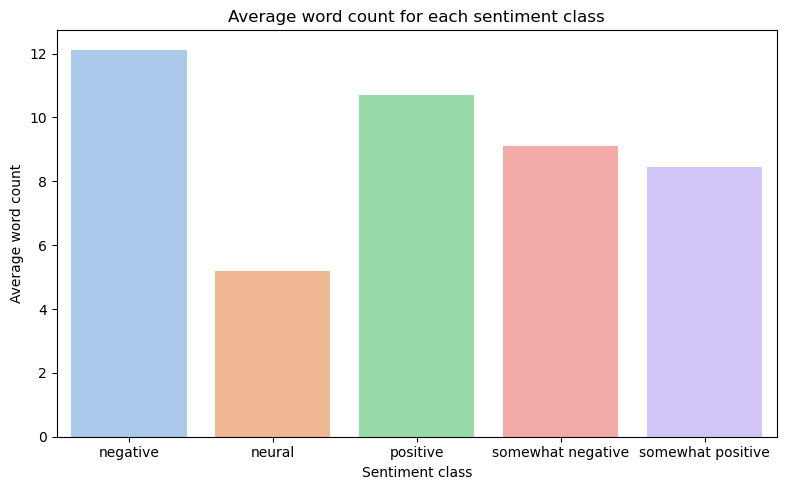

In [39]:
fig, ax = plt.subplots(1, 1, figsize=(8, 5))

sns.barplot(data=average_word_count, x="SentimentName", y="WordCount", palette="pastel", hue="SentimentName", ax=ax)

ax.set_title("Average word count for each sentiment class")
ax.set_xlabel("Sentiment class")
ax.set_ylabel("Average word count")

plt.tight_layout()
plt.show()

In [40]:
sns.histplot(data=word_count_df, x="Character count", color=color(), bins=70)

plt.title("Distribution of character count")
plt.show()

ValueError: Could not interpret value `Character count` for `x`. An entry with this name does not appear in `data`.

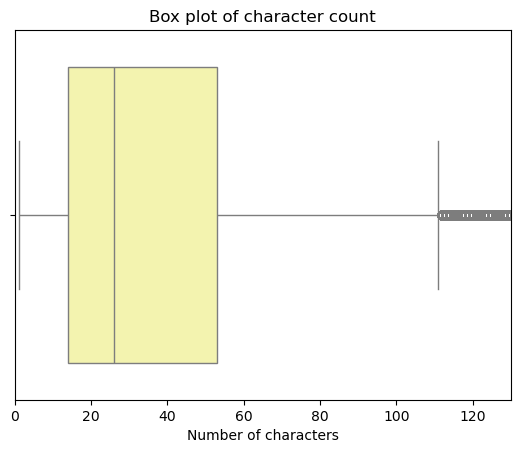

In [ ]:
sns.boxplot(data=word_count_df, x="Character count", color=color())

plt.xlim((0, 130))
plt.xlabel("Number of characters")
plt.title("Box plot of character count")
plt.show()

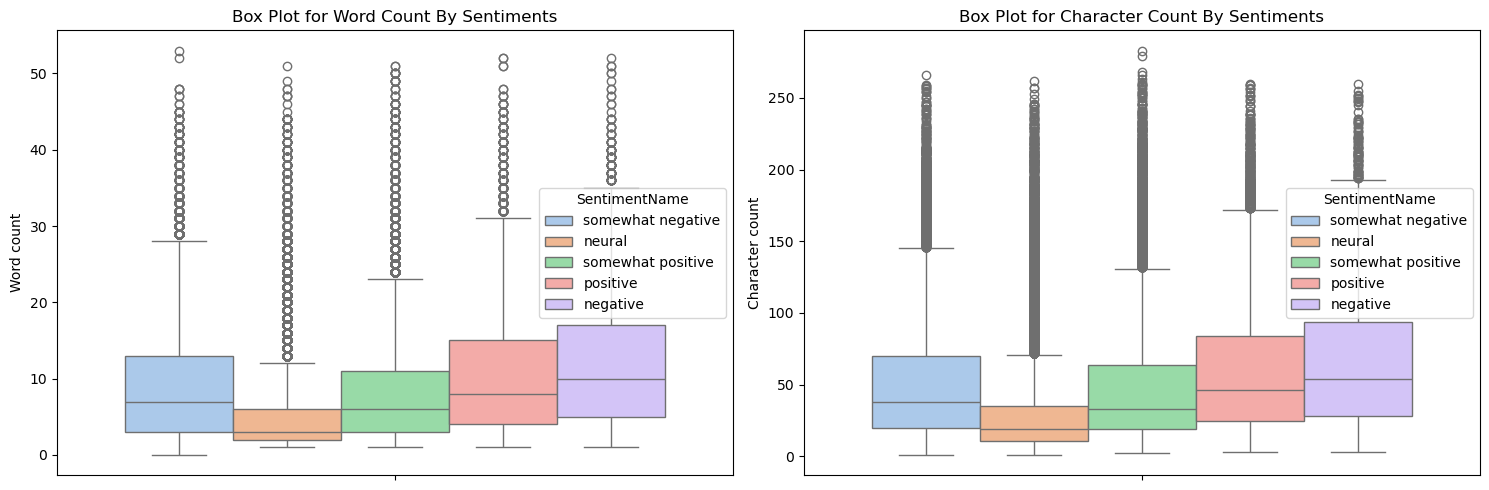

In [ ]:
# Figure
fig, axs = plt.subplots(1, 2, figsize=(15, 5))

# Pass result of seaborn to ax
sns.boxplot(
    data=word_count_df,
    y="Word count",
    hue="SentimentName",
    palette="pastel",
    ax=axs[0]
)
axs[0].set_title("Box Plot")

# Pass result of seaborn to ax
sns.boxplot(
    data=word_count_df,
    y="Character count",
    hue="SentimentName",
    palette="pastel",
    ax=axs[1]
)

# Configure each ax
axs[0].set_title("Box Plot for Word Count By Sentiments")
axs[1].set_title("Box Plot for Character Count By Sentiments")

plt.tight_layout()
plt.show()

In [ ]:
fig, axs = plt.subplots(1, 1, figsize=(7, 5))

# First plot
sns.boxplot(
    data=word_count_df,
    y="Word count",
    hue="SentimentName",
    palette="pastel",
    ax=axs
)
axs.set_title("Box Plot")

plt.tight_layout()
plt.show()

##### 💯 Result
- There are no substantial differences between the distribution of word count or character count between different sentiment classes (Though word count and character count in the case of negative phrases are a little bit higher compared with other classes)
---
##### 🌳 Possible decisions:
- some
---

#### 🦞 What are the most common words in different sentiment classes and word cloud for each classes?

In [44]:
summarize_df = eda_df.groupby("SentimentName")["Phrase"].aggregate(lambda serries: " ".join([phrase for phrase in serries]))

summarize_df = summarize_df.reset_index()

pd.reset_option('display.max_colwidth')
summarize_df.columns = ["SentimentName", "FullText"]

summarize_df.head()

,SentimentName,FullText
0,negative,would have a hard time sitting through this on...
1,neural,A series of escapades demonstrating the adage ...
2,positive,"This quiet , introspective and entertaining in..."
3,somewhat negative,A series of escapades demonstrating the adage ...
4,somewhat positive,"good for the goose good amuses This quiet , in..."


In [45]:

STOP_WORDS = set(stopwords.words("english"))

# possibly affect the sentiment
keep_words = {
    "no", "not", "never", "nor", "n't",
    "very", "too", "so", "only", "just",
    "but", "against", "up", "down",
    "more", "most", "less", "least"
}

contextual_words = {
    "movie", "film"
}

STOP_WORDS = STOP_WORDS.union(contextual_words) - keep_words

In [46]:
def simple_preprocess(text : str):
    lower = text.lower()
    
    lower = re.sub(pattern=r"[:,.]", repl=" ", string=lower)
    lower = re.sub(pattern=r"'s", repl=" ", string=lower)
    lower = re.sub(pattern=r"``", repl=" ", string=lower)
    lower = re.sub(pattern=r"--", repl=" ", string=lower)
    
    tokens = word_tokenize(lower)
    
    tokens = [token for token in tokens if token not in STOP_WORDS]
    
    return tokens

In [47]:

summarize_df["Preprocessed"] = summarize_df.apply(lambda row: simple_preprocess(row["FullText"]), axis=1)

In [48]:
summarize_df.head()

,SentimentName,FullText,Preprocessed
0,negative,would have a hard time sitting through this on...,"[would, hard, time, sitting, one, hard, time, ..."
1,neural,A series of escapades demonstrating the adage ...,"[series, escapades, demonstrating, adage, good..."
2,positive,"This quiet , introspective and entertaining in...","[quiet, introspective, entertaining, independe..."
3,somewhat negative,A series of escapades demonstrating the adage ...,"[series, escapades, demonstrating, adage, good..."
4,somewhat positive,"good for the goose good amuses This quiet , in...","[good, goose, good, amuses, quiet, introspecti..."


In [49]:
top = 15
name = f"Top{top}Word"

In [50]:
summarize_df["WordFrequency"] = summarize_df.apply(lambda row: Counter(row["Preprocessed"]), axis=1)
summarize_df[name] = summarize_df.apply(lambda row: row["WordFrequency"].most_common(top), axis=1)
top_word = summarize_df.apply(lambda row: pd.DataFrame(row[name], columns=["Word", "Frequency"]), axis=1)

In [51]:
n_df = top_word[0]

neu_df = top_word[1]

p_df = top_word[2]

sn_df = top_word[3]

sp_df = top_word[4]

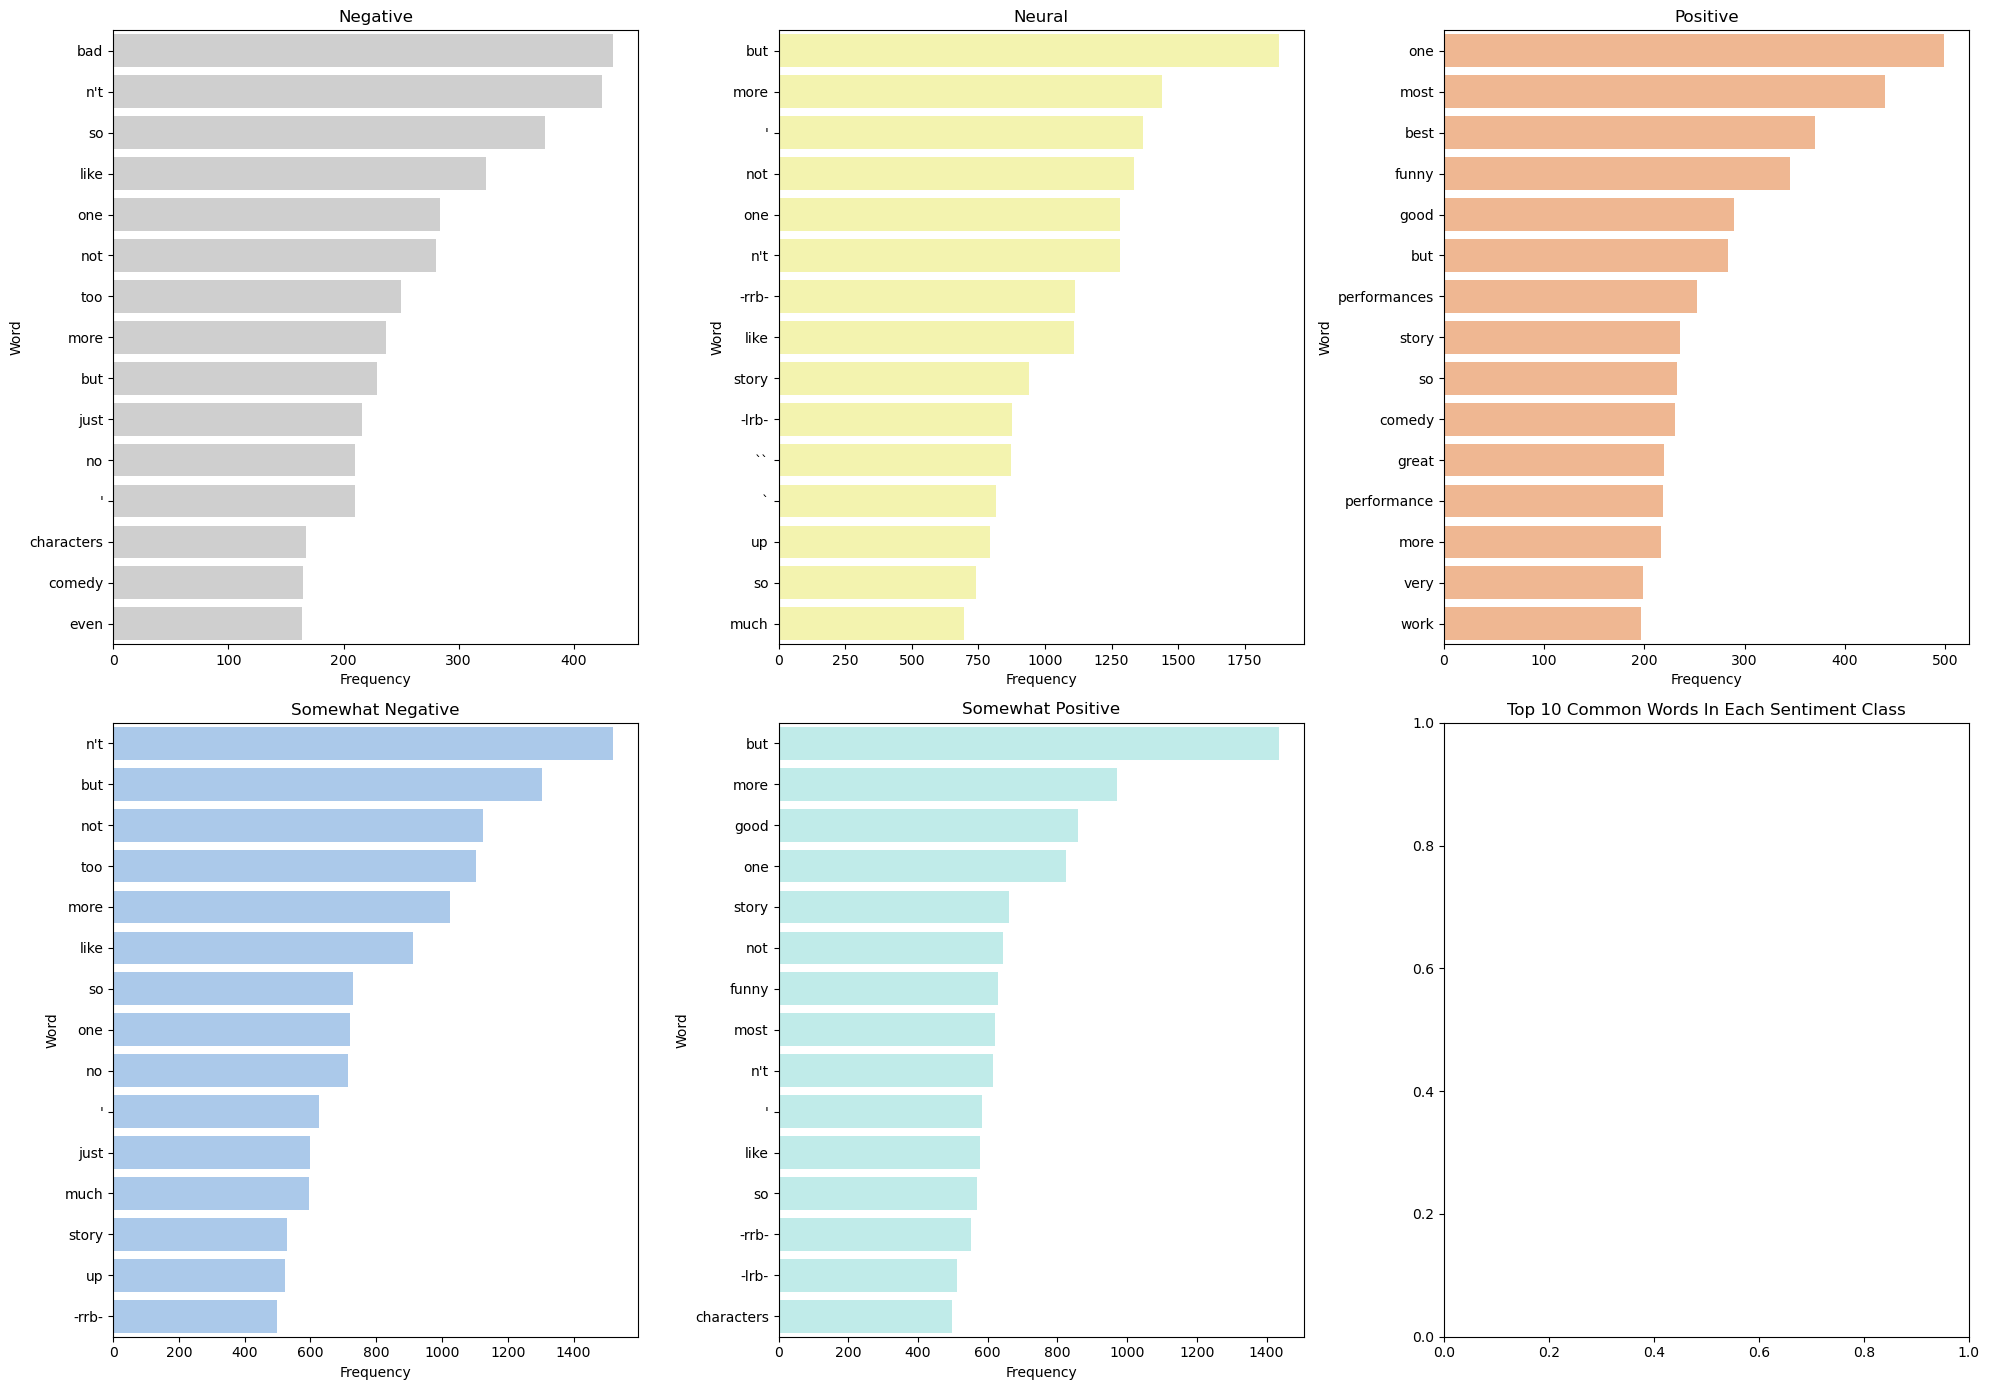

In [52]:
fig, axes = plt.subplots(2, 3, figsize=(20,14))


sns.barplot(
    data=n_df,
    y="Word",
    x="Frequency",
    color=color(),
    ax=axes[0][0]
)
axes[0][0].set_title("Negative")

sns.barplot(
    data=neu_df,
    y="Word",
    x="Frequency",
    color=color(),
    ax=axes[0][1]
)
axes[0][1].set_title("Neural")

sns.barplot(
    data=p_df,
    y="Word",
    x="Frequency",
    color=color(),
    ax=axes[0][2]
)
axes[0][2].set_title("Positive")

sns.barplot(
    data=sn_df,
    y="Word",
    x="Frequency",
    color=color(),
    ax=axes[1][0]
)
axes[1][0].set_title("Somewhat Negative")

sns.barplot(
    data=sp_df,
    y="Word",
    x="Frequency",
    color=color(),
    ax=axes[1][1]
)
axes[1][1].set_title("Somewhat Positive")

plt.tight_layout()
plt.title("Top 10 Common Words In Each Sentiment Class")
plt.show()

#### ☁️ Word clouds for differnet classes

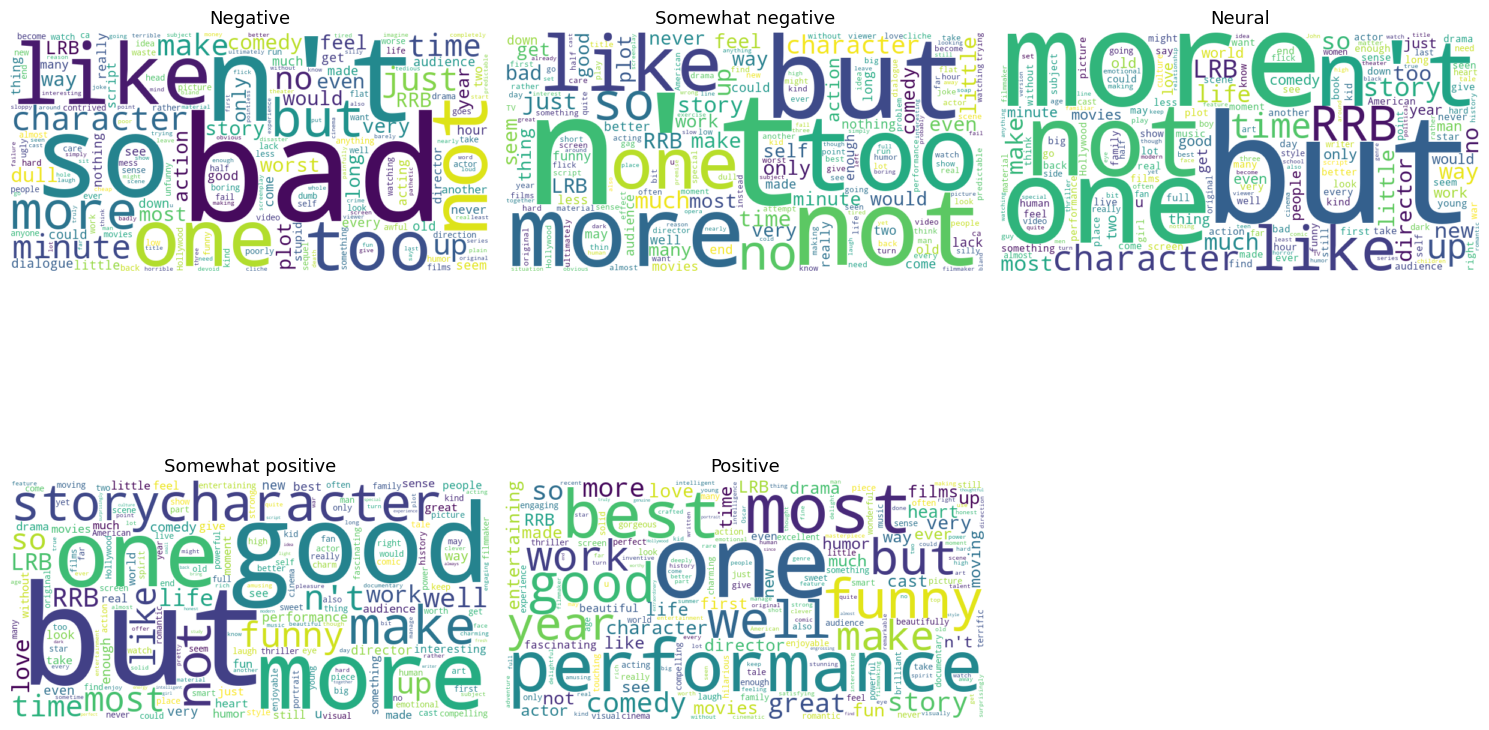

In [55]:
# subplots of axes from the figure
fig, axes = plt.subplots(2, 3, figsize=(15, 10))
axes = axes.flatten()

for i, sentiment in enumerate(sorted(eda_df["Sentiment"].unique())):
    
    # get all phrases of one sentiment
    subset = eda_df[eda_df["Sentiment"] == sentiment]
    
    # joining joining, same as before though
    text = " ".join(subset["Phrase"].astype(str))
    
    # draw, draw
    wordcloud = WordCloud(
        width=800,
        height=400,
        background_color='white',
        # to remove the stop words first
        # just like most common words
        stopwords=STOP_WORDS,
        collocations=False
    ).generate(text)
    
    axes[i].imshow(wordcloud, interpolation='bilinear')
    axes[i].axis("off")
    
    sentiment_name = sentiment_mappings[sentiment]
    # what the fuck, always fail to render icon
    # icon = icon_mappings[sentiment]
    axes[i].set_title(f"{sentiment_name.capitalize()}", fontsize=13)


for j in range(len(sentiment_mappings), len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()

##### 💯 Result
- The context stopwords are also removed for better visualization (movies, films)
- Each class with very distinctive words like negative -> bad, positive -> best
---
##### 🌳 Possible decisions:
- some
---

#### 🛕 Templates

---
##### 💯 Result
- some
---
##### 🌳 Possible decisions:
- some
---